In [12]:
import torch

# LIBRI TTS
sd = torch.load("/home/blue2959/monotonic_tts/runs/monotonic_tts_local_support_emission_vctk_20260515-035636/checkpoints/last.pth")

# VCTK
# sd = torch.load("/home/blue2959/monotonic_tts/runs/monotonic_tts_local_support_emission_vctk_20260514-090732/checkpoints/last.pth")

In [13]:
from pathlib import Path

import torch

from tts.config.stage1.data_config import DataConfig
from tts.config.stage1.model_config import MonotonicTTSConfigs
from tts.config.utils.io import load_config
from tts.models.init_monotonic_tts import init_monotonic_tts


# ------------------------------------------------------------
# 1. Checkpoint path
# ------------------------------------------------------------
# LIBRITTS? / current run
ckpt_path = Path(
    "/home/blue2959/monotonic_tts/runs/"
    + "monotonic_tts_local_support_emission_vctk_20260515-035636/"
    + "checkpoints/last.pth"
)

# VCTK
# ckpt_path = Path(
#     "/home/blue2959/monotonic_tts/runs/"
#     + "monotonic_tts_local_support_emission_vctk_20260514-090732/"
#     + "checkpoints/last.pth"
# )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# 2. Load configs from run directory
#    ckpt_path: run_dir/checkpoints/last.pth
# ------------------------------------------------------------
run_dir = ckpt_path.parent.parent

data_config_path = run_dir / "data_config.json"
model_config_path = run_dir / "model_config.json"

data_config = (
    load_config(str(data_config_path), DataConfig)
    if data_config_path.exists()
    else DataConfig()
)

model_config = (
    load_config(str(model_config_path), MonotonicTTSConfigs)
    if model_config_path.exists()
    else MonotonicTTSConfigs()
)


# ------------------------------------------------------------
# 3. Initialize model
# ------------------------------------------------------------
model = init_monotonic_tts(config=model_config).to(device)


# ------------------------------------------------------------
# 4. Load checkpoint
# ------------------------------------------------------------
ckpt = torch.load(ckpt_path, map_location=device)

if "model" in ckpt:
    state_dict = ckpt["model"]
else:
    state_dict = ckpt

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Loaded checkpoint:", ckpt_path)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

Loaded checkpoint: /home/blue2959/monotonic_tts/runs/monotonic_tts_local_support_emission_vctk_20260515-035636/checkpoints/last.pth
Missing keys: []
Unexpected keys: []


MonotonicTTSSynthesizer(
  (text_embedder): TextEmbedder(
    (out): Embedding(256, 256)
  )
  (crf_aligner): MonotonicCRFAligner(
    (unary_predictor): UNetUnaryPotentialPredictor(
      (spec_proj): Sequential(
        (0): Linear(in_features=256, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Linear(in_features=64, out_features=32, bias=True)
      )
      (text_proj): Sequential(
        (0): Linear(in_features=256, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Linear(in_features=64, out_features=32, bias=True)
      )
      (cond_proj): Linear(in_features=192, out_features=16, bias=True)
      (unet): UNet2d(
        (in_block): ResBlock2d(
          (block1): ConvNormAct2d(
            (conv): Conv2d(84, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): GroupNor

In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

from tts.data.tts_datafactory import TTSDataFactory


# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
target_text_len = 100
target_spec_len = 500
max_samples = 1000

device = next(model.parameters()).device  # model 변수가 이미 있다고 가정
model.eval()

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------
config = data_config
data_factory = TTSDataFactory(config)
loader = data_factory.train_loader  # or valid_loader


# ------------------------------------------------------------
# Accumulate interpolated attentions
# ------------------------------------------------------------
attn_sum = torch.zeros(
    target_text_len,
    target_spec_len,
    dtype=torch.float32,
    device="cpu",
)

num_seen = 0

with torch.no_grad():
    for batch in tqdm(loader, desc="Accumulating attention"):
        if num_seen >= max_samples:
            break

        x = batch.text.to(device)
        x_lengths = batch.text_lengths.to(device)
        y = batch.spec.to(device)
        y_lengths = batch.spec_lengths.to(device)
        cond = batch.cond.to(device)

        out = model(
            x=x,
            x_lengths=x_lengths,
            y=y,
            y_lengths=y_lengths,
            cond=cond,
            compute_viterbi_loss=False,
            compute_diagonal_loss=False,
        )

        # out.attn: (B, T_spec, T_text)
        attn = out.attn.detach()

        B = attn.size(0)
        remaining = max_samples - num_seen

        if B > remaining:
            attn = attn[:remaining]
            x_lengths_b = x_lengths[:remaining]
            y_lengths_b = y_lengths[:remaining]
            B = remaining
        else:
            x_lengths_b = x_lengths
            y_lengths_b = y_lengths

        batch_interp_list = []

        for b in range(B):
            s_len = int(y_lengths_b[b].item())
            t_len = int(x_lengths_b[b].item())

            # valid region만 crop: (T_spec_valid, T_text_valid)
            attn_b = attn[b, :s_len, :t_len]

            # (T_spec, T_text) -> (T_text, T_spec)
            attn_b = attn_b.transpose(0, 1)

            # (T_text, T_spec) -> (1, 1, T_text, T_spec)
            attn_b = attn_b.unsqueeze(0).unsqueeze(0)

            # fixed canvas로 interpolate
            attn_b = F.interpolate(
                attn_b.float(),
                size=(target_text_len, target_spec_len),
                mode="bilinear",
                align_corners=False,
            )

            # (1, 1, 100, 500) -> (100, 500)
            attn_b = attn_b.squeeze(0).squeeze(0)

            # ------------------------------------------------------------
            # text축 normalize
            # attn_b shape: (T_text_fixed, T_spec_fixed)
            # 각 spec column마다 text축 합이 1이 되도록
            # ------------------------------------------------------------
            denom = attn_b.sum(dim=0, keepdim=True).clamp_min(1e-8)
            attn_b = attn_b / denom

            batch_interp_list.append(attn_b)

        # (B, 100, 500)
        attn_interp = torch.stack(batch_interp_list, dim=0)

        attn_sum += attn_interp.cpu().sum(dim=0)
        num_seen += B

avg_attn = attn_sum / max(num_seen, 1)

[Info] Parsed 149736 items from libritts
[Info] Filtering items by duration (1.5s ~ 25.0s)...


Filtering data: 100%|██████████| 149736/149736 [01:38<00:00, 1517.76it/s]


[Info] Filtered 18537 items. Remaining: 131199
[Info] Data split complete: 129888 train, 1311 valid


Accumulating attention:   1%|          | 125/16236 [00:43<1:32:30,  2.90it/s]


num_seen: 1000
avg_attn: torch.Size([100, 500])


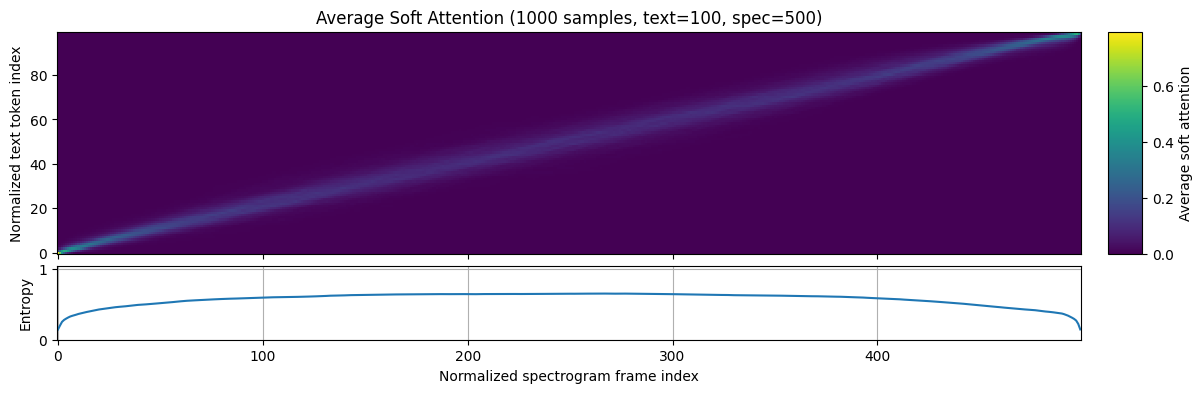

In [25]:
print("num_seen:", num_seen)
print("avg_attn:", avg_attn.shape)

# ------------------------------------------------------------
# Frame-wise entropy over text axis
# avg_attn: (T_text_fixed, T_spec_fixed)
# ------------------------------------------------------------
p = avg_attn.float()
p = p / p.sum(dim=0, keepdim=True).clamp_min(1e-8)

entropy = -(p * torch.log(p.clamp_min(1e-8))).sum(dim=0)
entropy_norm = entropy / torch.log(torch.tensor(float(target_text_len)))

# ------------------------------------------------------------
# Plot with separate colorbar axis
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 4))

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[30, 1],
    height_ratios=[3, 1],  # 기존 [4, 1]에서 줄임
    wspace=0.05,
    hspace=0.08,
)

ax_attn = fig.add_subplot(gs[0, 0])
ax_entropy = fig.add_subplot(gs[1, 0], sharex=ax_attn)
cax = fig.add_subplot(gs[0, 1])

# Empty axis under colorbar column
ax_empty = fig.add_subplot(gs[1, 1])
ax_empty.axis("off")

# 1. Average attention heatmap
im = ax_attn.imshow(
    avg_attn.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)

fig.colorbar(im, cax=cax, label="Average soft attention")

ax_attn.set_ylabel("Normalized text token index")
ax_attn.set_title(
    f"Average Soft Attention "
    + f"({num_seen} samples, text={target_text_len}, spec={target_spec_len})"
)

# Hide x tick labels on upper plot
plt.setp(ax_attn.get_xticklabels(), visible=False)

# 2. Frame-wise entropy
ax_entropy.plot(entropy_norm.numpy())
ax_entropy.set_xlabel("Normalized spectrogram frame index")
ax_entropy.set_ylabel("Entropy")
ax_entropy.set_ylim(0.0, 1.05)
ax_entropy.grid(True)

plt.show()

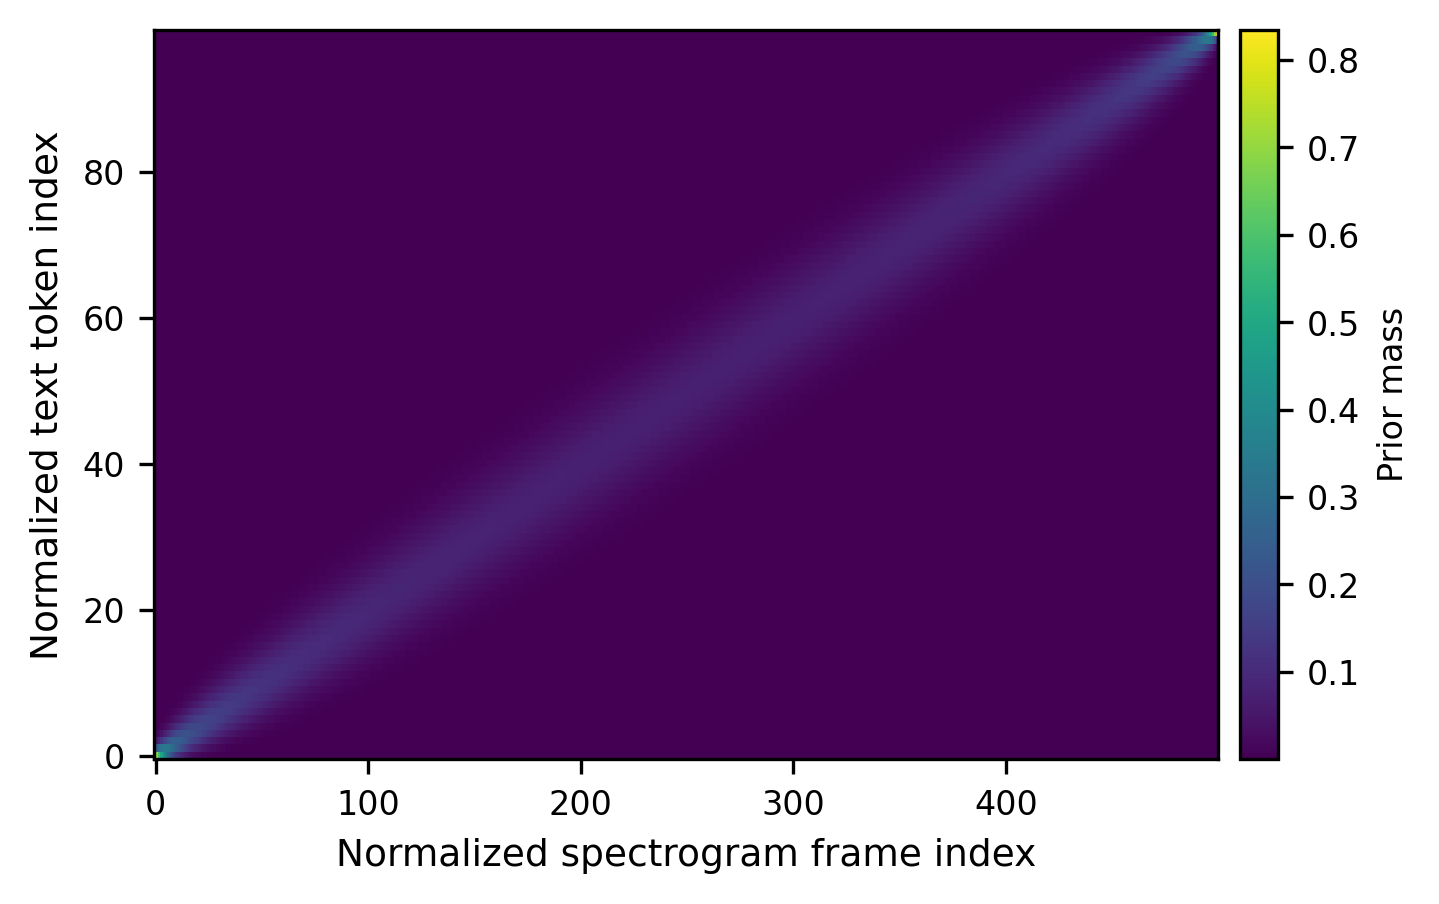

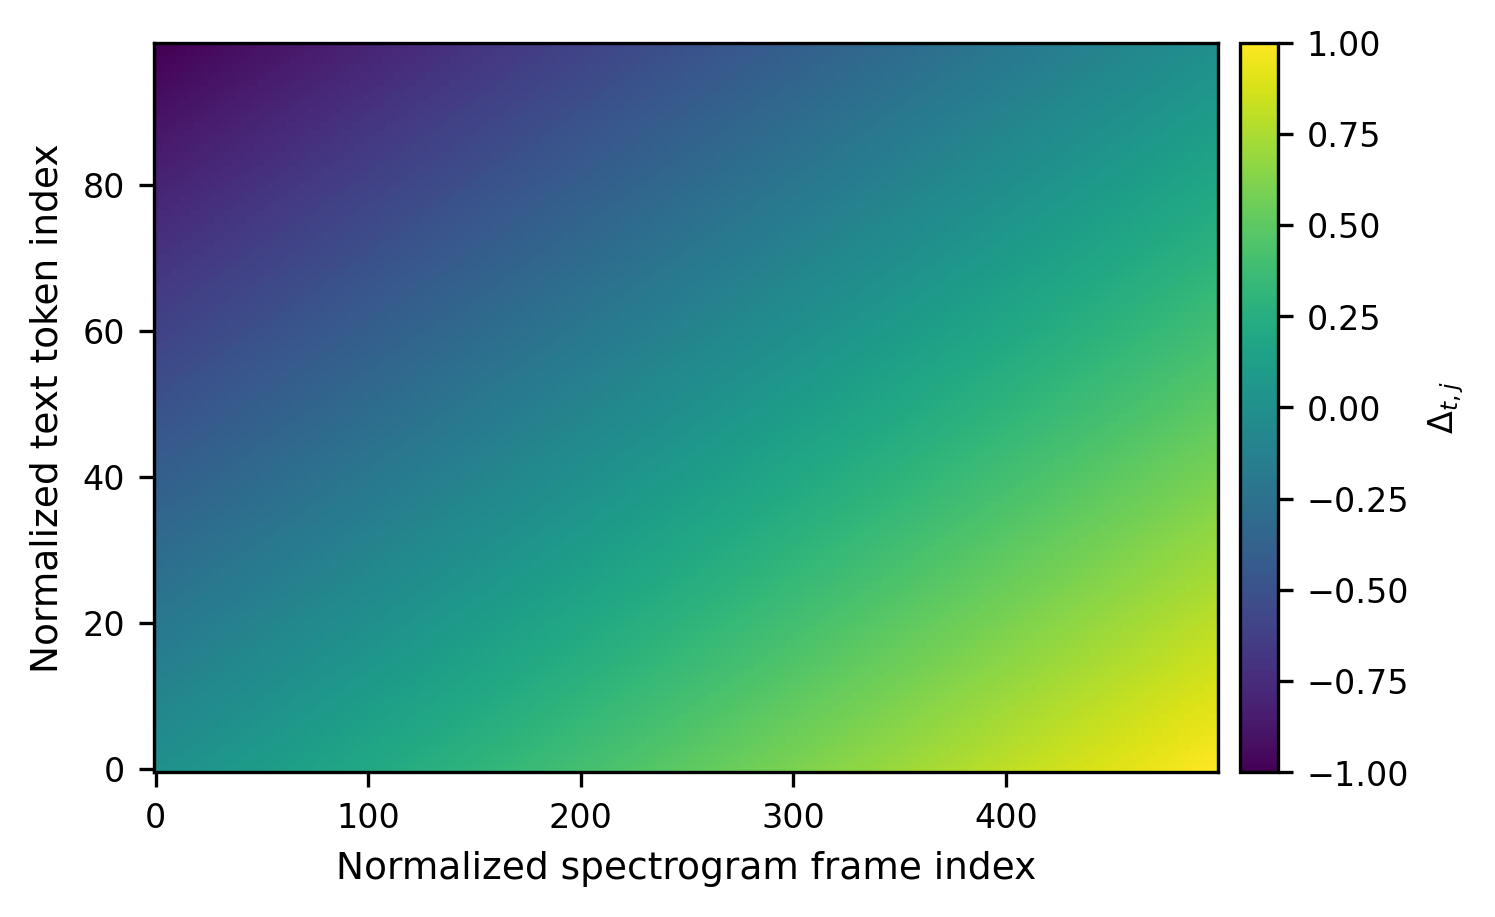

In [29]:
import os
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
target_text_len = 100
target_spec_len = 500
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

prior_scale = 1.0
dpi = 300

# 1행 4열 배치를 고려해서 가로 길이를 줄인 크기
figsize = (4.8, 3.2)

# 폰트도 조금 줄임
label_fs = 9
title_fs = 10
tick_fs = 8
cbar_fs = 8


# ------------------------------------------------------------
# Shared plot helper
# ------------------------------------------------------------
def save_heatmap_same_size(
    mat: torch.Tensor,
    filename: str,
    *,
    title: str | None = None,
    cbar_label: str,
    vmin=None,
    vmax=None,
):
    """
    Save heatmap with identical canvas/layout across figures.
    mat shape: (text_len, spec_len)
    """
    fig = plt.figure(figsize=figsize, dpi=dpi)

    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[28, 1],
        wspace=0.04,
        left=0.12,
        right=0.90,
        bottom=0.16,
        top=0.92 if title is None else 0.88,
    )

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    im = ax.imshow(
        mat.detach().cpu().numpy(),
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cbar_label, fontsize=cbar_fs)
    cb.ax.tick_params(labelsize=tick_fs)

    ax.set_xlabel("Normalized spectrogram frame index", fontsize=label_fs)
    ax.set_ylabel("Normalized text token index", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)

    if title is not None:
        ax.set_title(title, fontsize=title_fs)

    # bbox_inches="tight"는 저장 크기를 바꿀 수 있어서 일부러 안 씀
    fig.savefig(os.path.join(out_dir, filename), dpi=dpi)
    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# (a) Beta-binomial prior
# ------------------------------------------------------------
def beta_binomial_prior(
    text_len: int,
    spec_len: int,
    prior_scale: float = 1.0,
    eps: float = 1e-8,
) -> torch.Tensor:
    """
    Returns:
        prior: (text_len, spec_len)
               Each spectrogram frame column sums to 1 over text axis.
    """
    n = text_len - 1

    k = torch.arange(text_len, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    t = torch.arange(spec_len, dtype=torch.float32).unsqueeze(0)  # (1, T)

    alpha = prior_scale * (t + 1.0)
    beta = prior_scale * (spec_len - t)

    n_tensor = torch.tensor(float(n), dtype=torch.float32)

    log_comb = (
        torch.lgamma(n_tensor + 1.0)
        - torch.lgamma(k + 1.0)
        - torch.lgamma(n_tensor - k + 1.0)
    )

    log_beta_num = (
        torch.lgamma(k + alpha)
        + torch.lgamma(n_tensor - k + beta)
        - torch.lgamma(n_tensor + alpha + beta)
    )

    log_beta_den = (
        torch.lgamma(alpha)
        + torch.lgamma(beta)
        - torch.lgamma(alpha + beta)
    )

    log_p = log_comb + log_beta_num - log_beta_den
    log_p = log_p - torch.logsumexp(log_p, dim=0, keepdim=True)

    prior = torch.exp(log_p).clamp_min(eps)
    prior = prior / prior.sum(dim=0, keepdim=True).clamp_min(eps)

    return prior


prior = beta_binomial_prior(
    text_len=target_text_len,
    spec_len=target_spec_len,
    prior_scale=prior_scale,
)

save_heatmap_same_size(
    prior,
    "beta_binomial_prior.png",
    title=None,  # 논문용이면 None 추천
    cbar_label="Prior mass",
)


# ------------------------------------------------------------
# (c) Relative-progress feature
# ------------------------------------------------------------
def relative_progress_feature(
    text_len: int,
    spec_len: int,
) -> torch.Tensor:
    """
    Returns:
        delta: (text_len, spec_len)
               Delta_{t,j} = rho_t - nu_j
    """
    rho = torch.linspace(0.0, 1.0, spec_len).unsqueeze(0)  # (1, T)
    nu = torch.linspace(0.0, 1.0, text_len).unsqueeze(1)   # (N, 1)
    return rho - nu


delta = relative_progress_feature(
    text_len=target_text_len,
    spec_len=target_spec_len,
)

save_heatmap_same_size(
    delta,
    "relative_progress_feature.png",
    title=None,  # 논문용이면 None 추천
    cbar_label=r"$\Delta_{t,j}$",
    vmin=-1.0,
    vmax=1.0,
)

num_seen: 1000
avg_attn: torch.Size([100, 500])


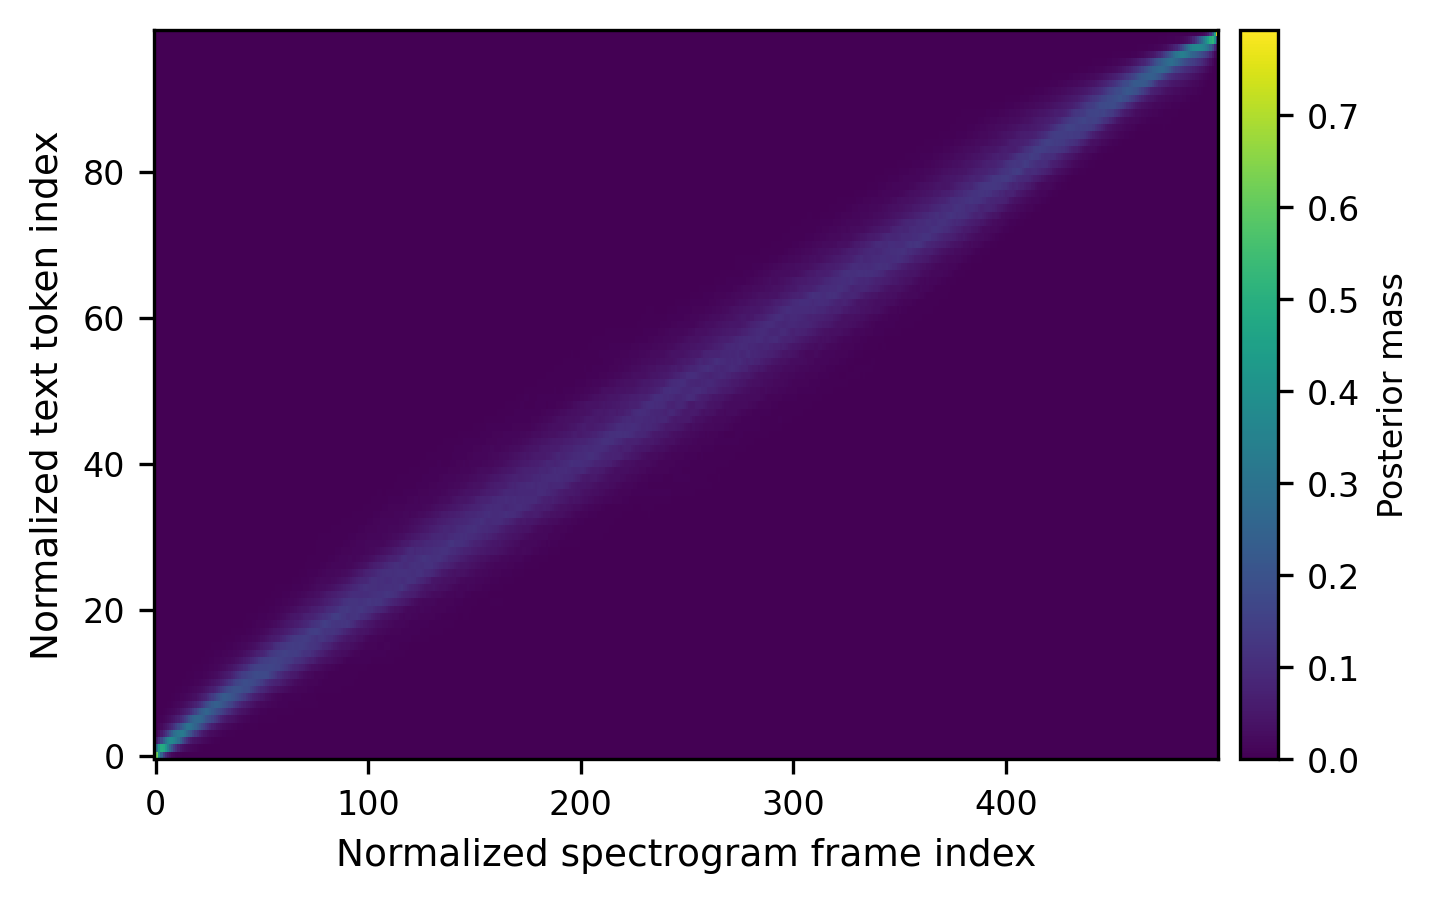

In [30]:
print("num_seen:", num_seen)
print("avg_attn:", avg_attn.shape)

# ------------------------------------------------------------
# Save average posterior occupancy with same format/size
# avg_attn: (T_text_fixed, T_spec_fixed)
# ------------------------------------------------------------

# Column-normalize over text axis for safety
avg_attn_plot = avg_attn.float()
avg_attn_plot = avg_attn_plot / avg_attn_plot.sum(dim=0, keepdim=True).clamp_min(1e-8)

save_heatmap_same_size(
    avg_attn_plot,
    "average_gamma.png",
    title=None,  # 논문용이면 title 없이 subcaption에만 설명
    cbar_label="Posterior mass",
)